# 01 · Research foundations for a synthetic claims/payment-integrity pipeline

This notebook takes the **three source papers** behind the project, states the estimator, test or
guarantee each one contributes, and checks it by simulation on CPU only against the package that
lives in `claims_integrity` (`ci.PACKAGE_VERSION == "1.0.0"`, deterministic, no network,
no GPU).

| Section | Paper | What is derived and verified here |
| --- | --- | --- |
| B | Ibrahim, Nguyen, Fu 2023, **arXiv:2306.03288** (CCEM) | Eq. (1)-(3) response model, Eq. (6a)-(6b) negative log-likelihood, Theorem 1 identification up to a label permutation, NCSA / NAPA |
| C | Xu, Guo, Wei 2025/26, **arXiv:2512.12844 v2** (SCRC) | selective coverage and conditional selected risk (Eq. 2, 3, 6), bounded monotone loss, first-stage threshold Eq. (11), conformal counting quantile Eq. (15), Theorem 2 exchangeability guarantee |
| D | Yu, Liu 2026, **arXiv:2606.08517** (SCoRC) | Algorithm 1 (failure budget `delta/3m`, Clopper-Pearson acceptance LCB, empirical-Bernstein risk/utility bounds, deterministic feasibility filter, `INFEASIBLE` branch), Assumptions 1-7, sample-size precondition, Theorem 1 joint certificate |
| E | cross-paper synthesis | the conditions all three sources leave unstated, measured here as explicit *derived falsifiers* |

**What this notebook is NOT.** No production claim of any kind is made: no claim about real payer
performance, no claim about protected health information, no real data anywhere. Every number
printed below is either (a) quoted from the papers with a label, or (b) produced by the
package's synthetic generator under a fixed seed. The narrowest true claim is: "the implemented
function reproduces the paper's stated algebra, and the simulated control behaves as the theorem
says under the theorem's own assumptions". Deployment questions (selection bias, drift,
dollar-weighted ranking, rejected-case safety) are *out of scope* for all three sources; section E
lists them as falsifiers, not as guarantees.

**Claim labels used throughout.**

| Label | Meaning |
| --- | --- |
| *source-backed* | traceable to an equation, theorem, assumption, table or page locator in one of the three papers |
| *derived here* | a project design choice: the synthetic generator, the CPU adaptation, a metric, a falsifier, a chart, a hand-made toy array |
| *out of scope* | explicitly not guaranteed or not covered by the source; no guarantee is inherited there |
| *preprint claim* | a SCoRC (`arXiv:2606.08517`) benchmark number; none is quoted |

**One palette for the whole notebook (Okabe-Ito).**
`#0072B2` blue = implemented / aligned / control ·
`#D55E00` vermillion = pre-alignment / warning ·
`#009E73` green = certified / audit / empirical-Bernstein ·
`#E69F00` orange = Hoeffding baseline ·
`#CC79A7` pink = annotation accent.

In [1]:
import sys
from pathlib import Path

_root = Path.cwd()
while not (_root / "claims_integrity").is_dir():
    if _root.parent == _root:
        raise RuntimeError("could not locate the project root from the working directory")
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import numpy as np
import matplotlib.pyplot as plt
import claims_integrity as ci

PALETTE = {
    "blue": "#0072B2",
    "vermillion": "#D55E00",
    "green": "#009E73",
    "orange": "#E69F00",
    "pink": "#CC79A7",
}
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 9,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
%matplotlib inline

In [2]:
print("check 1: the project package imports and the generator is deterministic")
print("  package", ci.PACKAGE_VERSION, "| root", _root.name)
print(
    "  frozen config: n_claims",
    ci.CONFIG["n_claims"],
    "| alpha",
    ci.CONFIG["alpha"],
    "| alpha_sensitivity",
    ci.CONFIG["alpha_sensitivity"],
    "| delta",
    ci.CONFIG["delta"],
    "| k_latent",
    ci.CONFIG["k_latent"],
    "| n_reviewers",
    ci.CONFIG["n_reviewers"],
)
print("  seeds", tuple(ci.CONFIG["seeds"]))
_digest_a = ci.stream_digest(ci.make_claim_stream(seed=11, n=64, regime="anchored"))
_digest_b = ci.stream_digest(ci.make_claim_stream(seed=11, n=64, regime="anchored"))
assert _digest_a == _digest_b
print("  generator digest on two identical calls:", _digest_a[:16], "... (equal)")
assert ci.PACKAGE_VERSION.startswith("1.0.0")

check 1: the project package imports and the generator is deterministic
  package 1.0.0 | root claims-payment-integrity-labels
  frozen config: n_claims 1500 | alpha 0.05 | alpha_sensitivity 0.1 | delta 0.1 | k_latent 3 | n_reviewers 6
  seeds (11, 23, 37, 53)
  generator digest on two identical calls: 602875fe8091ab02 ... (equal)


## B · Paper 1 — CCEM: coupled cross-entropy minimization for noisy reviewer labels

**Claim under test (CCEM Eq. (1)-(3)).** Each claim `x_n` has a latent class
`y_n in [K]`, each reviewer `m` has a *column-stochastic* confusion matrix `A_m`, and the observed
response distribution is the coupled matrix-vector form

> "`p_n^(m) = A_m f(x_n), for all m in [M], n in [N]` --- Eq. (2)"

with the response drawn as a categorical realisation

> "`yhat_n^(m) ~ Cart(p_n^(m))` --- Eq. (3)", i.e. "The observed noisy label is a categorical
> realization drawn from this distribution" — CCEM Eq. (3)

Here `[f(x_n)]_k = Pr(y_n = k | x_n)` is the ground-truth predictor and
`A_m(k, k') = Pr(yhat_n^(m) = k | y_n = k')` (Eq. (1)). Our public helpers take the transposed
convention `confusion[r, latent, observed] = A_r^T`, which is the package's documented test contract.

**Objective (CCEM Eq. (6a)-(6b)).** CCEM minimises "the empirical negative
log-likelihood over observed annotations `(m,n) in S`" jointly in `f` and the matrices `{A_m}`,
subject to `f in F` and `A_m in A` (non-negative, column-stochastic). `ci.ccem_objective` evaluates
that observed-label NLL and `ci.fit_ccem` performs the joint fit.

**Identification (CCEM Thm 1, NCSA, NAPA).** Theorem 1 identifies the optimum
only "up to an inherent label permutation matrix `Pi`", written into Eq. (7a)-(7b):

> "`min_Pi || Ahat_m - A_m^natural Pi ||_F^2 <= K sigma^2 (eta + xi_1 + xi_2)` --- Eq. (7a)"

with `Pi` a column permutation matrix. Two assumptions make that permutation resolvable:
**NCSA** — "there exists at least one annotator `m_k` specialized in class `k` such that
`||A^natural_{m_k}(k, :) - e_k^T||_2 <= xi_1`" — and **NAPA** — "there exists at least one
near-anchor data item `x_{n_k}` such that `||f^natural(x_{n_k}) - e_k||_2 <= xi_2`". The finite-sample
error term is `eta + xi_1 + xi_2` (statistical error plus the two geometric gaps); no stronger
guarantee is claimed.

**Derived here (the CPU adaptation).** Our implementation is a *derived computational adaptation*:
a numpy/scipy linear-softmax classifier with per-reviewer column-stochastic confusion matrices
(`ci.fit_ccem` with L-BFGS-B and an identity-like near-specialist prior on `A_m`), preserving
Eq. (1)-(3) and Eq. (6).The paper's identifiability
algebra does not require a neural architecture — Eq. (7a)-(7b) analyse the `A_m f(x)` structure
itself. Anything about the synthetic claim stream, the specialist queue, or the weak-anchor stress
arm is *derived here*, not paper-backed.

**Checks in this section.** (i) reproduce a hand-computed 2x2 probability/NLL case against
Eq. (2)/Eq. (6a); (ii) check the analytic gradient of `fit_ccem`'s objective against central finite
differences — this temporarily wraps `scipy.optimize.minimize` *as seen by the package's `ccem`
module* to capture the closure's objective, and restores it in a `finally` block (the package is not
modified, and this is a *derived here* verification device); (iii) fit on a synthetic anchored
stream and report the recovered permutation, the latent error before and after alignment, the
confusion-matrix error and the unresolved mass; (iv) show that the likelihood is invariant under a
class relabelling, so only the aligned error means anything.

**Paper's own experiments (CCEM Section 5 and Supp. N), NOT reproduced here.** Ibrahim,
Nguyen and Fu evaluate GeoCrowdNet(F)/(W) against **7 baselines** (TraceReg, MBEM, CrowdLayer, CoNAL, Max-MIG,
NN-MV, NN-DSEM) on synthetic hammer-spammer CIFAR-10, machine-annotator MNIST/Fashion-MNIST (an NCSA-holds case
with expert annotators and an NCSA-violates case with none), and two real AMT-labelled sets (LabelMe, Music).
Two headline rows, quoted for orientation only — Section 5 Table 1-2 and Supp. Table 3, p. 7-8/19:

| Setting | GeoCrowdNet(F) | Best baseline | Worst baseline |
| --- | --- | --- | --- |
| CIFAR-10, `gamma=0.01` (high expertise) | **84.82 +/- 0.43** | TraceReg 82.54 +/- 0.34 | NN-MV 50.96 +/- 0.83 |
| LabelMe (`M=59, K=8`) | **85.85 +/- 0.33** | Max-MIG 85.03 +/- 0.44 | NN-DSEM 78.26 +/- 1.18 |

Confusion-matrix recovery error on CIFAR-10 (`gamma=0.01`) is MSE 0.088 for GeoCrowdNet(F) versus 0.097 for
plain CCEM (`lambda=0`) — Supp. Figs. 3 and 5, p. 20/22. All annotators are neural/SVM/kNN classifiers or
AMT workers on real images and audio; **none of this notebook's numbers come from that pipeline**, and no
number above is reproduced by the synthetic claims stream below.

**Paper's stated limitations (CCEM Section 6 / Assumption scope).** The paper leaves four
things unsettled that this project's synthetic design has to invent on its own, each labelled `derived here`
when it appears later: (1) no reviewer-selection or dynamic routing mechanism — annotator-item pairs are
observed uniformly at random (Assumption 1); (2) no non-i.i.d. or instance-dependent noise handling — annotator
error is class-conditional but instance-independent; (3) no cost-sensitive loss or financial utility — the
objective is unweighted log-likelihood; (4) no heavy-tailed dollar amounts or continuous outcomes — `y` is
strictly categorical. The claims stream's specialist queue, weak-anchor stress arm, and dollar proxy exist precisely because the source paper is silent on all four.

In [3]:
posterior_small = np.array([[0.7, 0.3], [0.2, 0.8]])
confusion_small = np.array([[[0.9, 0.1], [0.2, 0.8]], [[0.6, 0.4], [0.3, 0.7]]])
observed_small = np.array([[0, 1], [1, 0]])
expected_probs = np.array([[[0.69, 0.31], [0.51, 0.49]], [[0.34, 0.66], [0.36, 0.64]]])

probs = ci.ccem_observed_probability(posterior_small, confusion_small)
hand_nll = -np.mean(np.log([0.69, 0.49, 0.66, 0.36]))
nll = ci.ccem_objective(posterior_small, observed_small, confusion_small)

print("check 2: Eq. (2) probabilities on the hand-computed 2x2 case")
print("  shape", probs.shape, "= (item, reviewer, observed)")
print("  item 0, reviewer 0:", probs[0, 0], "| item 0, reviewer 1:", probs[0, 1])
print("  item 1, reviewer 0:", probs[1, 0], "| item 1, reviewer 1:", probs[1, 1])
assert probs.shape == (2, 2, 2)
assert np.allclose(probs, expected_probs, atol=1e-12)

print("check 3: Eq. (6a) NLL on the same case")
picked = [probs[0, 0, 0], probs[0, 1, 1], probs[1, 0, 1], probs[1, 1, 0]]
print("  picked probabilities for the observed labels:", [round(float(p), 6) for p in picked])
print("  NLL", round(nll, 12), "| hand-computed", round(float(hand_nll), 12))
assert abs(nll - float(hand_nll)) < 1e-12

check 2: Eq. (2) probabilities on the hand-computed 2x2 case
  shape (2, 2, 2) = (item, reviewer, observed)
  item 0, reviewer 0: [0.69 0.31] | item 0, reviewer 1: [0.51 0.49]
  item 1, reviewer 0: [0.34 0.66] | item 1, reviewer 1: [0.36 0.64]
check 3: Eq. (6a) NLL on the same case
  picked probabilities for the observed labels: [0.69, 0.49, 0.66, 0.36]
  NLL 0.63039506519 | hand-computed 0.63039506519


In [4]:
import claims_integrity.ccem as ccem_module

captured = {}
_original_minimize = ccem_module.minimize


def _capture_objective(fun, x0, *args, **kwargs):
    captured["fun"] = fun
    captured["x0"] = np.asarray(x0, dtype=float).copy()
    return _original_minimize(fun, x0, *args, **kwargs)


probe_rng = np.random.default_rng(5)
probe_features = probe_rng.normal(size=(8, 3))
probe_labels = probe_rng.integers(0, 2, size=(8, 2))

ccem_module.minimize = _capture_objective
try:
    ci.fit_ccem(probe_features, probe_labels, k=2, n_reviewers=2, seed=3, max_iter=2, n_restarts=1)
finally:
    ccem_module.minimize = _original_minimize

objective = captured["fun"]
x_init = captured["x0"]
loss_at_init, analytic_grad = objective(x_init)
eps = 1e-6
fd_grad = np.zeros_like(x_init)
for index in range(x_init.size):
    step = np.zeros_like(x_init)
    step[index] = eps
    fd_grad[index] = (objective(x_init + step)[0] - objective(x_init - step)[0]) / (2.0 * eps)

max_abs = float(np.max(np.abs(fd_grad - analytic_grad)))
print("check 4: analytic gradient of the fit_ccem objective vs central finite differences")
print("  probe problem: 8 items, 3 features, 2 latent classes, 2 reviewers")
print("  parameter vector size", x_init.size, "| objective at init", round(loss_at_init, 10))
print("  max |analytic - finite difference| =", f"{max_abs:.3e}")
assert np.allclose(fd_grad, analytic_grad, rtol=1e-4, atol=1e-6)
print("check 4: PASS - every gradient coordinate agrees to finite-difference accuracy")

check 4: analytic gradient of the fit_ccem objective vs central finite differences
  probe problem: 8 items, 3 features, 2 latent classes, 2 reviewers
  parameter vector size 16 | objective at init 0.7393528372
  max |analytic - finite difference| = 8.421e-11
check 4: PASS - every gradient coordinate agrees to finite-difference accuracy


In [5]:
stream = ci.make_claim_stream(seed=11, n=800, regime="anchored")
k = int(stream["config"]["k_latent"])
labels = stream["reviewer_label_matrix"]
warm_start = ci.vote_posterior(labels, k, stream["class_prior"])
fit = ci.fit_ccem(
    stream["features"],
    labels,
    k=k,
    n_reviewers=int(stream["config"]["n_reviewers"]),
    seed=11,
    n_restarts=2,
    posterior_init=warm_start,
)
true_posterior = stream["latent_posterior_true"]

permutation, aligned = ci.align_posteriors(true_posterior, fit["posterior"])
err_identity = float(((fit["posterior"] - true_posterior) ** 2).sum(axis=1).mean())
err_aligned = float(((aligned - true_posterior) ** 2).sum(axis=1).mean())

aligned_confusion = np.empty_like(fit["confusion"])
aligned_confusion[:, np.asarray(permutation), :] = fit["confusion"]
confusion_error = float(
    np.abs(aligned_confusion - stream["reviewer_confusion_true"]).mean(axis=(1, 2)).mean()
)
unresolved_mass = float((1.0 - aligned.max(axis=1)).mean())

print("check 5: CCEM fit on the synthetic anchored stream (seed 11, n = 800)")
print("  recovered permutation map (truth class -> estimate column):", permutation)
print("  latent error with the identity permutation     :", round(err_identity, 5))
print("  latent error after Hungarian alignment         :", round(err_aligned, 5))
print("  reviewer confusion-matrix error (aligned)      :", round(confusion_error, 5))
print("  unresolved mass 1 - max aligned posterior      :", round(unresolved_mass, 5))
print(
    "  fit loss",
    round(fit["loss"], 5),
    "| iterations",
    fit["n_iterations"],
    "| converged",
    fit["converged"],
    "| annotations",
    fit["n_annotations"],
)
assert sorted(permutation) == list(range(k))
assert err_aligned <= err_identity + 1e-15
assert err_aligned < 0.05
assert confusion_error < 0.15

check 5: CCEM fit on the synthetic anchored stream (seed 11, n = 800)
  recovered permutation map (truth class -> estimate column): (0, 1, 2)
  latent error with the identity permutation     : 0.02141
  latent error after Hungarian alignment         : 0.02141
  reviewer confusion-matrix error (aligned)      : 0.08189
  unresolved mass 1 - max aligned posterior      : 0.16296
  fit loss 0.7738 | iterations 30 | converged True | annotations 2400


In [6]:
demo_permutation = (1, 2, 0)
relabelled = fit["posterior"][:, list(demo_permutation)]
relabelled_confusion = fit["confusion"][:, list(demo_permutation), :]
nll_fit = ci.ccem_objective(fit["posterior"], labels, fit["confusion"])
nll_relabelled = ci.ccem_objective(relabelled, labels, relabelled_confusion)
recovered, relabelled_aligned = ci.align_posteriors(true_posterior, relabelled)
err_relabelled_before = float(((relabelled - true_posterior) ** 2).sum(axis=1).mean())
err_relabelled_after = float(((relabelled_aligned - true_posterior) ** 2).sum(axis=1).mean())

boot_rng = np.random.default_rng(11)


def bootstrap_interval(values):
    draws = boot_rng.choice(values, size=(2000, values.size), replace=True).mean(axis=1)
    low, high = np.percentile(draws, [2.5, 97.5])
    return float(low), float(high)


per_item_fit = ((fit["posterior"] - true_posterior) ** 2).sum(axis=1)
per_item_before = ((relabelled - true_posterior) ** 2).sum(axis=1)
per_item_after = ((relabelled_aligned - true_posterior) ** 2).sum(axis=1)
ci_fit = bootstrap_interval(per_item_fit)
ci_before = bootstrap_interval(per_item_before)
ci_after = bootstrap_interval(per_item_after)

print("check 6: the likelihood cannot see the permutation, so only the aligned error is meaningful")
print("  NLL as fitted     :", round(nll_fit, 12))
print("  NLL after relabel :", round(nll_relabelled, 12), "(identical to machine precision)")
print("  permutation recovered for the relabelled copy:", recovered)
print(
    "  identity-permutation error of the relabelled copy:",
    round(err_relabelled_before, 5),
    "95% bootstrap CI",
    tuple(round(v, 5) for v in ci_before),
)
print(
    "  aligned error of the same relabelled copy         :",
    round(err_relabelled_after, 5),
    "95% bootstrap CI",
    tuple(round(v, 5) for v in ci_after),
)
print(
    "  reference: the fitted model's own aligned error    :",
    round(err_aligned, 5),
    "95% bootstrap CI",
    tuple(round(v, 5) for v in ci_fit),
)
print("  ratio identity / aligned:", round(err_relabelled_before / err_relabelled_after, 1))
assert abs(nll_fit - nll_relabelled) < 1e-12
assert tuple(recovered) == tuple(np.argsort(demo_permutation))
assert err_relabelled_before > 20.0 * err_relabelled_after
assert abs(err_relabelled_after - err_aligned) < 1e-9

check 6: the likelihood cannot see the permutation, so only the aligned error is meaningful
  NLL as fitted     : 0.770411819529
  NLL after relabel : 0.770411819529 (identical to machine precision)
  permutation recovered for the relabelled copy: (2, 0, 1)
  identity-permutation error of the relabelled copy: 1.39725 95% bootstrap CI (1.38167, 1.41304)
  aligned error of the same relabelled copy         : 0.02141 95% bootstrap CI (0.02015, 0.02279)
  reference: the fitted model's own aligned error    : 0.02141 95% bootstrap CI (0.02016, 0.02282)
  ratio identity / aligned: 65.2


### How to read this chart

Two views of the *same* fitted CCEM solution, with 95% bootstrap intervals over the 800 synthetic
claims. The vermillion bar is the relabelled copy scored under the **identity** permutation — the
number you would report if you forgot that Theorem 1 only identifies the model up to a label
permutation. The blue bar is that same copy after the Hungarian mapping to the truth. **Higher error
means less identifiable recovery; the gap between the bars is exactly the permutation ambiguity
Theorem 1 warns about**, and the two likelihoods are identical to machine precision, so the raw
(identity) number measures the relabelling, not the estimator's quality. The dashed green line is
the fitted model's own aligned error, which the relabelled copy recovers after alignment. The bars
are not a comparison of two models: they are one model, read two ways.

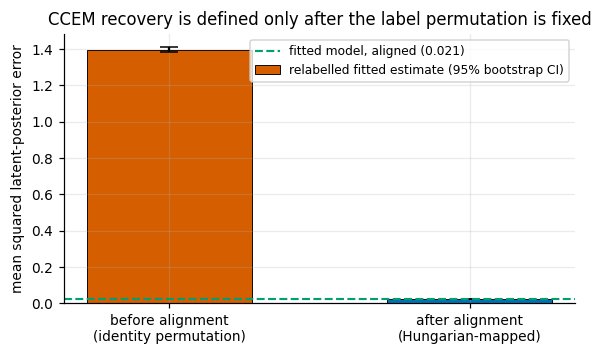

In [7]:
fig, ax = plt.subplots(figsize=(5.4, 3.3))
bar_labels = ["before alignment\n(identity permutation)", "after alignment\n(Hungarian-mapped)"]
bar_values = [err_relabelled_before, err_relabelled_after]
bar_lower = [bar_values[0] - ci_before[0], bar_values[1] - ci_after[0]]
bar_upper = [ci_before[1] - bar_values[0], ci_after[1] - bar_values[1]]
ax.bar(
    [0, 1],
    bar_values,
    yerr=[bar_lower, bar_upper],
    capsize=6,
    width=0.55,
    color=[PALETTE["vermillion"], PALETTE["blue"]],
    edgecolor="black",
    linewidth=0.6,
    label="relabelled fitted estimate (95% bootstrap CI)",
)
ax.axhline(
    err_aligned,
    color=PALETTE["green"],
    linestyle="--",
    linewidth=1.4,
    label=f"fitted model, aligned ({err_aligned:.3f})",
)
ax.set_xticks([0, 1])
ax.set_xticklabels(bar_labels)
ax.set_ylabel("mean squared latent-posterior error")
ax.set_title("CCEM recovery is defined only after the label permutation is fixed")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

### How to read this chart

Every reviewer's confusion matrix, true versus recovered, after the Hungarian alignment fixes the label
permutation (Theorem 1). Top row: `A_m^natural`, the generator's ground truth. Bottom row: `aligned_confusion`,
the CCEM fit's column-stochastic estimate, permuted into the same class order. Rows of each 3x3 panel are the
true class, columns are the predicted/observed class; a well-recovered reviewer looks diagonal in both rows and
the two panels in a column look alike. This is a standard crowdsourcing-literature diagnostic (Dawid-Skene /
CCEM confusion recovery) that a single scalar error cannot show: it separates *which* reviewers and *which*
class pairs drive the aggregate `confusion_error` printed above, not just its mean.

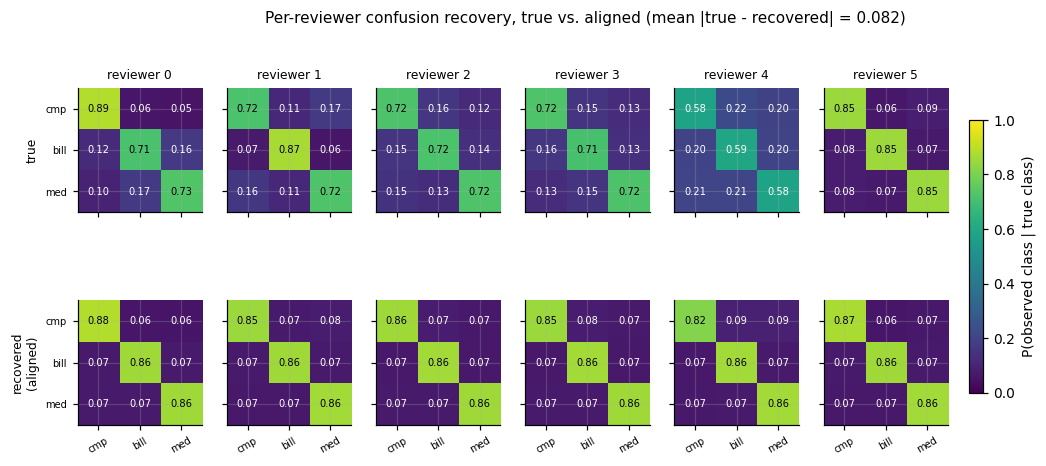

In [8]:
fig, axes = plt.subplots(2, aligned_confusion.shape[0], figsize=(2.05 * aligned_confusion.shape[0], 4.6))
class_labels = ["cmp", "bill", "med"]  # CLASS_NAMES abbreviated: compliant/billing_error/medically_unnecessary
matrices = {"true": stream["reviewer_confusion_true"], "recovered\n(aligned)": aligned_confusion}
for row_index, (row_title, mats) in enumerate(matrices.items()):
    for reviewer in range(mats.shape[0]):
        ax = axes[row_index, reviewer]
        im = ax.imshow(mats[reviewer], vmin=0.0, vmax=1.0, cmap="viridis")
        for r in range(mats.shape[1]):
            for col in range(mats.shape[2]):
                value = mats[reviewer, r, col]
                ax.text(col, r, f"{value:.2f}", ha="center", va="center", fontsize=6.5,
                        color="white" if value < 0.6 else "black")
        ax.set_xticks(range(len(class_labels)))
        ax.set_yticks(range(len(class_labels)))
        if row_index == 1:
            ax.set_xticklabels(class_labels, fontsize=6.5, rotation=30)
        else:
            ax.set_xticklabels([])
            ax.set_title(f"reviewer {reviewer}", fontsize=8)
        ax.set_yticklabels(class_labels if reviewer == 0 else [], fontsize=6.5)
        if reviewer == 0:
            ax.set_ylabel(row_title, fontsize=8)
fig.suptitle(
    f"Per-reviewer confusion recovery, true vs. aligned (mean |true - recovered| = {confusion_error:.3f})",
    fontsize=10,
)
fig.colorbar(im, ax=axes, shrink=0.7, label="P(observed class | true class)", pad=0.02)
plt.show()

## C · Paper 2 — SCRC: selective coverage and conditional selected risk

**Claim under test (SCRC Eq. (2), (3), (6)).** SCRC post-processes a fixed base
classifier `f` and a fixed selection score `g` with two calibration parameters
`(lambda_1, lambda_2)`: abstain when `g(x) < 1 - lambda_1`, and otherwise predict the set
`C_{lambda_2}(x) = {k : f(x)_k >= 1 - lambda_2}`. The two published quantities are the selective
coverage

> "`phi(f, g) = P(g(X) >= 1 - lambda)` --- Eq. (2)"

and the conditional selected risk

> "`R(f, g) = E[l(C_{lambda_2}(X_{n+1}), Y_{n+1}) | g(X_{n+1}) >= 1 - lambda_1]` --- Eq. (6)"

**Loss requirement (SCRC loss monotonicity).** The second-stage loss must be
bounded and monotone: "The loss must be monotonically non-increasing in `lambda_2` (i.e., loss
decreases as prediction set size expands)"; the CRC counting quantile is only valid for such
a loss (SCRC Thm 2). Our derived binary routing collapse keeps that shape: `l in [0, 1]` and
non-increasing as the acceptance rule loosens.

**Procedures (SCRC Eq. (11) and Eq. (15)).** The first-stage selection
threshold is

> "`lambda_hat_1 = inf {lambda_1 in Lambda_1 : R_hat_{n+1}^{(1)}(lambda_1) <= 1 - xi}` --- Eq. (11)"

and the second-stage threshold is the conformal counting quantile

> "`lambda_hat_2 = inf {lambda_2 in Lambda_2 : sum over (X_i,Y_i) in Z_lambda_bar_1 of
> l(C_{lambda_2}(X_i), Y_i) <= ceil((m+1) alpha) - 1}` --- Eq. (15)"

which needs `m >= m_min = ceil(1/alpha) - 1` to be non-trivial (feasibility remark).

**Guarantee (SCRC Thm 2).** Under the exchangeability condition

> "Calibration and test samples `(X_i, Y_i)_{i=1}^{n+1}` are exchangeable" — Theorem 2

the direction of each claim is: selection coverage is bounded **below**
(`P(g(X_{n+1}) >= 1 - lambda_bar_1) >= xi`) and the conditional selected risk is bounded **above**
(`E[l | accepted] <= alpha`). Both are conditional on the selected subpopulation; rejected cases
carry no second-stage guarantee at all (Section 6 limitation).

**Paper-reported numbers (source-backed, NOT ours) — SCRC Tables 1 and 2, p. 14-15.** Each
cell is an empirical risk at `xi = 0.70`, `alpha = 0.10`, averaged over 100 random splits:

| Dataset / model | `delta = 0.01` | `delta = 0.05` | `delta = 0.10` |
| --- | --- | --- | --- |
| CIFAR-10 / ResNet-18 (Table 1) | 0.0954 | 0.0960 | 0.0964 |
| Diabetic retinopathy / ResNet-34 (Table 2) | 0.0931 | 0.0935 | 0.0937 |

These are the paper's own numbers on real image datasets. They are *source-backed paper numbers*
quoted for orientation only: nothing in this notebook reproduces them, and the synthetic claims
below are a different task.

**Derived here.** The package collapses SCRC onto a one-stage routing rule
(`ci.scrc_inductive_policy`) because the synthetic action space is binary (auto-pay versus route to
review), not a prediction-set family. The exchangeable control below is therefore a *simulation of
the procedure under the theorem's assumption*, not a reproduction of the paper's tables, and it runs
at its own `alpha = 0.10`.

In [9]:
scrc = ci.scrc_exchangeable_control()
print("check 7: SCRC-I exchangeable control (derived simulation, n_seeds=200, n_cal=1000, n_test=4000)")
print("  target alpha                    :", scrc["alpha"])
print(
    "  mean realized selected risk     :",
    round(scrc["mean_test_risk"], 6),
    "95% CI",
    tuple(round(v, 6) for v in scrc["risk_interval"]),
)
print(
    "  mean selective coverage         :",
    round(scrc["mean_test_coverage"], 6),
    "| coverage floor xi",
    scrc["xi"],
)
print("  infeasible runs                 :", scrc["infeasible_runs"], "/", scrc["n_seeds"])
print(
    "  raw single-run exceedance rate  :",
    round(scrc["exceedance_rate"], 4),
    "95% Wilson CI",
    tuple(round(v, 4) for v in scrc["exceedance_interval"]),
)
print("  honesty note                    :", scrc["note"])
assert scrc["mean_test_risk"] <= scrc["alpha"]
print("check 7: PASS - mean realized selected risk sits at or below the target on this simulation")
print("  derived-here numbers: not a reproduction of the paper's tables and not a production claim")

check 7: SCRC-I exchangeable control (derived simulation, n_seeds=200, n_cal=1000, n_test=4000)
  target alpha                    : 0.1
  mean realized selected risk     : 0.096199 95% CI (0.095214, 0.097184)
  mean selective coverage         : 0.940771 | coverage floor xi 0.5
  infeasible runs                 : 1 / 200
  raw single-run exceedance rate  : 0.305 95% Wilson CI (0.2454, 0.372)
  honesty note                    : single-run test-sample noise dominates the raw exceedance rate; the reported control is the mean realized selected risk against the target alpha
check 7: PASS - mean realized selected risk sits at or below the target on this simulation
  derived-here numbers: not a reproduction of the paper's tables and not a production claim


## D · Paper 3 — SCoRC: a joint finite-sample certificate over risk, acceptance and utility

**Claim under test (SCoRC definitions and Alg. 1).** Algorithm 1 certifies a
finite grid of candidate policies `(lambda, tau) in Lambda x T` with `m = |Lambda x T|` jointly on
three population quantities on a certification split `D_cert`:

> "`R_sel(lambda, tau) = E[A(lambda, tau) L(lambda)] / E[A(lambda, tau)] = E[A L] / p_acc`
> (defined for `p_acc > 0`)"

> "`p_acc(lambda, tau) = P(A(lambda, tau) = 1) = E[A(lambda, tau)]`"

> "`U_dep(lambda, tau) = E[V(lambda, tau)] = E[A v - (1 - A) c] in [-c_max, V_max]`"

with per-sample `A_i = 1{g(X_i; tau) >= 1 - lambda}`, `L_i = l(C_lambda(X_i), Y_i) in [0, B]`,
`Z_i = A_i (L_i - alpha)` and `V_i = A_i v_i - (1 - A_i) c_i`.

**Algorithm 1 (SCoRC Alg. 1, Section 3.5 p. 5).** "Divide total failure
probability budget `delta` equally into three parts ... allocating local confidence parameter
`delta_0 = delta/(3m)` per grid point" (union bound over the grid). Then for each candidate:

1. **acceptance LCB** — exact Clopper-Pearson inversion,
   "`p_acc_LCB(lambda, tau) = Beta(delta/(3m); k_acc, n_cert - k_acc + 1)`";
2. **risk UCB** — variance-adaptive empirical Bernstein,
   "`epsilon_Z = sqrt(2 sigma_hat_Z^2 log(3m/delta)/n_cert) + 7 B log(3m/delta)/(3 (n_cert - 1))`",
   combined with the shifted mean as "`R_sel_UCB = alpha + (Z_bar + epsilon_Z)/p_acc_LCB`";
3. **utility LCB** — the same Bernstein shape with bound `V_max + c_max`:
   "`U_dep_LCB = V_bar - epsilon_V`";
4. **deterministic feasibility filter** —
   "`G_cert = {(lambda, tau) : R_sel_UCB <= alpha AND p_acc_LCB >= pi_min}`";
5. **INFEASIBLE branch** — "If `G_cert = empty`: The algorithm terminates immediately and returns
   `INFEASIBLE`"; otherwise "`(lambda_hat, tau_hat) = argmax U_dep_LCB` over `G_cert`".

**Sample-size precondition (SCoRC Assumption 5, Eq. (1)).**
"`n_cert >= 32 log(32m/delta)/pi_min`" — a strict precondition, surfaced as the per-row
`sample_size_ok` flag in the package.

**The seven assumptions (SCoRC Assumptions 1-7).** (1) calibration instances
are i.i.d. draws from `P_XY`; (2) bounded loss `L in [0, B]`, value `v in [0, V]`, cost `c >= 0`,
with the loss *arbitrarily non-monotone*; (3) the candidate grid is finite and the maps are
measurable; (4) `(alpha, pi_min, delta)` are pre-specified; (5) the sample-size precondition above;
(6) a disjoint three-way split `D_tr, D_tune, D_cert`, with the grid and the targets built only on
`D_tr` and `D_tune`; (7) *selector independence* — constructing `g` from `D_cert`
("certify-learned") "is strictly forbidden".

**Guarantee (SCoRC Thm 1).** Conditional on `(D_tr, D_tune)`, with probability
at least `1 - delta` over `D_cert`, Algorithm 1 "either returns `INFEASIBLE` or returns a certified
policy" satisfying the three claims simultaneously: `R_sel <= alpha`, `p_acc >= pi_min`, and
`U_dep >= U*_margin - 2 gamma_u` (a margin-oracle utility bound with radius `gamma_u`).

**SCoRC benchmark numbers are not quoted.** The SCoRC experiments are a preprint result that this notebook does not
reproduce; no SCoRC benchmark number is quoted anywhere in it. What the notebook does instead is *derived
here*: simulate the claimed tighter-than-Hoeffding regime with the package's own control and with
the two slack formulas. The rate comparison itself is source-backed (SCoRC Thm 8 / Cor. 6):
range-only Hoeffding forces a margin of `Omega(B sqrt(log(1/delta)) / (pi_min sqrt(n_cert)))`, and
SCoRC "sharpens this floor rate from `O(1/pi_min)` to `O(1/sqrt(pi_min))`".

**Where each package call comes from.**

| Package element | Paper element | Status |
| --- | --- | --- |
| `ci.clopper_pearson_lcb` | Algorithm 1 step 1 / Lemma 2 | source-backed |
| `ci.empirical_bernstein_slack` | Theorem 1 Eq. (3) slack term | source-backed |
| `ci.scorec_certificate` | Algorithm 1: budget, three bounds, filter, `argmax`, `INFEASIBLE` | source-backed |
| `ci.scorec_certificate_control` | the i.i.d. certification protocol of Assumptions 1 and 6 | derived here (simulation) |
| toy candidate grid below | accept masks, bounded losses, values and costs as proxies for auto-pay value / review cost | derived here |

In [10]:
scorec = ci.scorec_certificate_control()
print("check 8: SCoRC Algorithm 1 control (derived simulation, n_seeds=200, n_cert=1500, delta=0.10)")
print("  certified runs / infeasible runs :", scorec["certified_runs"], "/", scorec["infeasible_runs"])
print("  risk violation rate              :", scorec["risk_violation_rate"])
print("  acceptance violation rate        :", scorec["acceptance_violation_rate"])
print("  utility violation rate           :", scorec["utility_violation_rate"])
print(
    "  joint coverage                   :",
    scorec["joint_coverage"],
    "95% CI",
    tuple(round(v, 4) for v in scorec["joint_coverage_interval"]),
)
print("  Theorem 1 target (1 - delta)     :", scorec["guarantee_target"])
print(
    "  mean EB slack vs mean Hoeffding  :",
    round(scorec["mean_eb_slack"], 6),
    "vs",
    round(scorec["mean_hoeffding_slack"], 6),
    "| ratio",
    round(scorec["slack_ratio"], 4),
)
print("  note                             :", scorec["note"])
assert scorec["certified_runs"] + scorec["infeasible_runs"] == scorec["n_seeds"]
assert scorec["joint_coverage"] >= scorec["guarantee_target"]
assert scorec["risk_violation_rate"] <= 1.0 - scorec["joint_coverage"]
print("check 8: PASS - joint coverage meets the 1 - delta target under i.i.d. certification data")
print("  the SCoRC paper's benchmark numbers are not quoted; these are our simulation, not the paper's")

check 8: SCoRC Algorithm 1 control (derived simulation, n_seeds=200, n_cert=1500, delta=0.10)
  certified runs / infeasible runs : 200 / 0
  risk violation rate              : 0.0
  acceptance violation rate        : 0.0
  utility violation rate           : 0.005
  joint coverage                   : 0.995 95% CI (0.9722, 0.9991)
  Theorem 1 target (1 - delta)     : 0.9
  mean EB slack vs mean Hoeffding  : 0.015451 vs 0.041605 | ratio 0.3714
  note                             : independent certification/test splits
check 8: PASS - joint coverage meets the 1 - delta target under i.i.d. certification data
  the SCoRC paper's benchmark numbers are not quoted; these are our simulation, not the paper's


In [11]:
triples = [(8, 10, 0.05), (0, 10, 0.05), (10, 10, 0.05), (8, 10, 0.01), (8, 10, 0.10)]
bounds = [ci.clopper_pearson_lcb(k_, n_, q_) for (k_, n_, q_) in triples]
print("check 9: exact Clopper-Pearson lower confidence bound (Algorithm 1, step 1)")
for (k_, n_, q_), bound in zip(triples, bounds):
    print(
        f"  Clopper-Pearson LCB(k={k_}, n={n_}, q={q_}) = {bound:.6f}"
        f"   (k/n = {k_ / n_:.3f})"
    )
assert bounds[1] == 0.0
assert bounds[3] <= bounds[0] <= bounds[4]
assert all(bound <= k_ / n_ + 1e-12 for (k_, n_, _), bound in zip(triples, bounds))
print("check 9: PASS - monotone in the confidence level, zero at k = 0, never above k/n")

check 9: exact Clopper-Pearson lower confidence bound (Algorithm 1, step 1)
  Clopper-Pearson LCB(k=8, n=10, q=0.05) = 0.493099   (k/n = 0.800)
  Clopper-Pearson LCB(k=0, n=10, q=0.05) = 0.000000   (k/n = 0.000)
  Clopper-Pearson LCB(k=10, n=10, q=0.05) = 0.741134   (k/n = 1.000)
  Clopper-Pearson LCB(k=8, n=10, q=0.01) = 0.388257   (k/n = 0.800)
  Clopper-Pearson LCB(k=8, n=10, q=0.1) = 0.550396   (k/n = 0.800)
check 9: PASS - monotone in the confidence level, zero at k = 0, never above k/n


In [12]:
ledger_rng = np.random.default_rng(7)
n_cert_demo = 600
scores_demo = ledger_rng.random(n_cert_demo)
loss_demo = (ledger_rng.random(n_cert_demo) < (0.002 + 0.02 * (1.0 - scores_demo))).astype(float)
value_demo = np.ones(n_cert_demo)
cost_demo = np.full(n_cert_demo, 0.5)
candidates = [
    {
        "name": f"thr{threshold:.2f}",
        "accept": scores_demo >= threshold,
        "loss": loss_demo,
        "value": value_demo,
        "cost": cost_demo,
    }
    for threshold in (0.95, 0.30, 0.05)
]
ledger = ci.scorec_certificate(
    candidates,
    alpha=0.05,
    pi_min=0.50,
    delta=0.10,
    loss_bound=1.0,
    value_bound=1.0,
    cost_bound=0.5,
)

print("check 10: SCoRC Algorithm 1 ledger on a hand-built 3-candidate toy grid")
print(
    "  n_cert",
    ledger["n_cert"],
    "| m 3 | delta/(3m)",
    round(ledger["delta_per_point"], 6),
    "| log(3m/delta)",
    round(ledger["log_term"], 6),
    "| n_star",
    round(ledger["n_star"], 3),
)
for row in ledger["ledger"]:
    print(
        "  "
        + row["name"].ljust(10)
        + f" accepted={row['accept_count']:3d}"
        + f"  acceptance_lcb={row['acceptance_lcb']:.4f}"
        + f"  risk_ucb={row['risk_ucb']:.4f}"
        + f"  utility_lcb={row['utility_lcb']:.4f}"
        + f"  feasible={row['feasible']}"
        + f"  sample_size_ok={row['sample_size_ok']}"
    )
print("  chosen policy:", ledger["chosen"]["name"], "|", ledger["reason"])
feasible_rows = [row for row in ledger["ledger"] if row["feasible"]]
assert 0 < len(feasible_rows) < len(ledger["ledger"])
assert ledger["chosen"]["name"] == max(feasible_rows, key=lambda row: row["utility_lcb"])["name"]
assert abs(ledger["delta_per_point"] - 0.10 / (3 * 3)) < 1e-12
print("check 10: PASS - the filter excludes the acceptance-starved candidate and the argmax is certified")

check 10: SCoRC Algorithm 1 ledger on a hand-built 3-candidate toy grid
  n_cert 600 | m 3 | delta/(3m) 0.011111 | log(3m/delta) 4.49981 | n_star 439.484
  thr0.95    accepted= 26  acceptance_lcb=0.0265  risk_ucb=0.6772  utility_lcb=-0.4987  feasible=False  sample_size_ok=True
  thr0.30    accepted=432  acceptance_lcb=0.6759  risk_ucb=0.0387  utility_lcb=0.4712  feasible=True  sample_size_ok=True
  thr0.05    accepted=571  acceptance_lcb=0.9277  risk_ucb=0.0416  utility_lcb=0.8618  feasible=True  sample_size_ok=True
  chosen policy: thr0.05 | utility-maximising certified grid point
check 10: PASS - the filter excludes the acceptance-starved candidate and the argmax is certified


In [13]:
empty_grid = ci.scorec_certificate(
    [candidates[0]],
    alpha=0.05,
    pi_min=0.50,
    delta=0.10,
    loss_bound=1.0,
    value_bound=1.0,
    cost_bound=0.5,
)
repeat = ci.scorec_certificate(
    candidates,
    alpha=0.05,
    pi_min=0.50,
    delta=0.10,
    loss_bound=1.0,
    value_bound=1.0,
    cost_bound=0.5,
)
print("check 11: deterministic filter and the INFEASIBLE branch")
print("  grid with only the strict candidate ->", empty_grid["feasible"], "|", empty_grid["reason"])
print("  same grid called twice ->", ledger["chosen"]["name"], "and", repeat["chosen"]["name"])
assert empty_grid["feasible"] is False and empty_grid["chosen"] is None
assert repeat["chosen"]["name"] == ledger["chosen"]["name"]
print("check 11: PASS - an empty certified set returns INFEASIBLE and the result is reproducible")

check 11: deterministic filter and the INFEASIBLE branch
  grid with only the strict candidate -> False | INFEASIBLE: no certified grid point
  same grid called twice -> thr0.05 and thr0.05
check 11: PASS - an empty certified set returns INFEASIBLE and the result is reproducible


In [14]:
slack_m = 6
slack_delta = 0.10
slack_sigma2 = 0.01
slack_bound = 1.0
slack_log_term = float(np.log(3.0 * slack_m / slack_delta))
n_grid = np.unique(np.logspace(1.0, 6.0, 80).astype(int))
eb_slack = np.array(
    [
        ci.empirical_bernstein_slack(slack_sigma2, slack_bound, int(n_value), slack_log_term)
        for n_value in n_grid
    ]
)
hoeffding_slack = np.sqrt(slack_log_term / (2.0 * n_grid))
crossing = n_grid[eb_slack < hoeffding_slack]

print("check 12: empirical-Bernstein vs Hoeffding slack as a function of n_cert")
print(
    "  fixed sigma2 =",
    slack_sigma2,
    "| bound B =",
    slack_bound,
    "| m =",
    slack_m,
    "| delta =",
    slack_delta,
    "| log(3m/delta) =",
    round(slack_log_term, 6),
)
print("  n grid:", int(n_grid[0]), "to", int(n_grid[-1]), "(", n_grid.size, "points )")
print(
    "  EB < Hoeffding from n =",
    int(crossing[0]),
    "onward:",
    crossing.size,
    "of",
    n_grid.size,
    "grid points",
)
print(
    "  ratio EB/Hoeffding: max",
    round(float((eb_slack / hoeffding_slack).max()), 3),
    "| at n =",
    int(n_grid[-1]),
    round(float(eb_slack[-1] / hoeffding_slack[-1]), 4),
)
assert crossing.size > 0
assert eb_slack[-1] < hoeffding_slack[-1]
print("check 12: PASS - the variance-adaptive slack dominates in its stated large-n regime")

check 12: empirical-Bernstein vs Hoeffding slack as a function of n_cert
  fixed sigma2 = 0.01 | bound B = 1.0 | m = 6 | delta = 0.1 | log(3m/delta) = 5.192957
  n grid: 10 to 1000000 ( 80 points )
  EB < Hoeffding from n = 102 onward: 64 of 80 grid points
  ratio EB/Hoeffding: max 2.842 | at n = 1000000 0.2075
check 12: PASS - the variance-adaptive slack dominates in its stated large-n regime


### How to read this chart

Both curves are per-candidate concentration slacks at the same confidence budget `log(3m/delta)`,
with a fixed variance `sigma2 = 0.01`, a fixed bound `B = 1` and `m = 6` grid points, plotted
against the certification size `n_cert` on a log x-axis. The orange Hoeffding slack decays only like
`sqrt(1/n)` and ignores the variance; the green empirical-Bernstein slack adds a
`7 B log(3m/delta) / (3 (n_cert - 1))` finite-n penalty, so it is **looser for very small
`n_cert`** and **tighter once `n_cert` is large enough for the variance term to dominate**. The
vertical dotted line marks the crossing (`n ~= 102` here): to the right is the regime the paper's
Corollary 6 rate comparison describes, to the left the range-only bound is the safer choice. This is
a *derived-here* evaluation of the two published formulas on a fixed toy variance, not a SCoRC
benchmark number, and it says nothing about a particular dataset's realised risk.

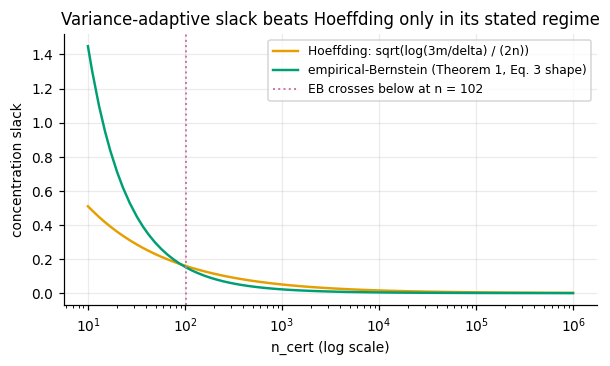

In [15]:
fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.plot(
    n_grid,
    hoeffding_slack,
    color=PALETTE["orange"],
    linewidth=1.6,
    label="Hoeffding: sqrt(log(3m/delta) / (2n))",
)
ax.plot(
    n_grid,
    eb_slack,
    color=PALETTE["green"],
    linewidth=1.6,
    label="empirical-Bernstein (Theorem 1, Eq. 3 shape)",
)
ax.axvline(
    int(crossing[0]),
    color=PALETTE["pink"],
    linestyle=":",
    linewidth=1.3,
    label=f"EB crosses below at n = {int(crossing[0])}",
)
ax.set_xscale("log")
ax.set_xlabel("n_cert (log scale)")
ax.set_ylabel("concentration slack")
ax.set_title("Variance-adaptive slack beats Hoeffding only in its stated regime")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

## E · Cross-paper synthesis: what none of the three sources guarantees

All three sources are silent on the same operational conditions. Each silence is an *out of scope*
boundary in the source, and this project turns it into an explicit **derived falsifier** that a
later notebook measures on purpose.

| Unstated condition | Where each source excludes it | Status for this project |
| --- | --- | --- |
| reviewer-selection bias | SCRC needs exchangeable calibration (Thm 2) and models no annotator noise ("No Reviewer Noise or Multi-Annotator Modeling"); SCoRC Assumption 7 forbids building `g` on `D_cert` | out of scope; measured as a derived falsifier |
| non-i.i.d. / non-exchangeable calibration | SCRC Thm 2 exchangeability; SCoRC Assumption 1 i.i.d. | out of scope; the calibration-sampling comparison below is the smallest honest probe |
| heavy-tailed dollars | SCRC optimises prediction-set size, not money ("No Ranking under a Fixed Dollar Budget or Portfolio Optimization"); SCoRC's utility is bounded by `V_max` and `c_max` | out of scope; the dollar proxy is bounded and explicitly derived |
| rejected-case safety | SCRC Section 6 limitation: "it does not provide a second-stage prediction-set guarantee for rejected samples" | out of scope; routed-to-review claims carry no claim here |
| drift | a shifted deployment distribution "violates Assumption 1" and collapses the binomial and Bernstein quantiles | out of scope; monitors are descriptive only |

The closing comparison is the smallest honest version of the first two rows: two hand-made
five-number arrays of calibration losses, one from a reviewer-selected arm and one from a randomized
audit. `ci.compare_calibration_sampling` reports the difference with a **bootstrap 95% interval over
the arrays** (2,000 resamples) and stamps the result with its real status: the selected arm sits
outside the exchangeability / selector-independence conditions, so it is an *assumption falsifier* —
`certificate_valid = False`, and no guarantee is inherited in either direction. A met target there is
**not** a restored guarantee, and a missed target is **not** a theorem failure.

In [16]:
selected_losses = np.array([0.09, 0.11, 0.10, 0.12, 0.08])
audit_losses = np.array([0.03, 0.02, 0.04, 0.05, 0.02])
comparison = ci.compare_calibration_sampling(selected_losses, audit_losses, seed=11)

arm_rng = np.random.default_rng(11)


def arm_interval(values):
    draws = arm_rng.choice(values, size=(2000, values.size), replace=True).mean(axis=1)
    low, high = np.percentile(draws, [2.5, 97.5])
    return float(low), float(high)


selected_ci = arm_interval(selected_losses)
audit_ci = arm_interval(audit_losses)
print("check 13: reviewer-selected vs randomized-audit calibration (assumption falsifier)")
print(
    "  reviewer-selected mean loss :",
    round(comparison["selected_mean"], 5),
    "95% bootstrap CI",
    tuple(round(v, 5) for v in selected_ci),
)
print(
    "  randomized-audit mean loss  :",
    round(comparison["audit_mean"], 5),
    "95% bootstrap CI",
    tuple(round(v, 5) for v in audit_ci),
)
print(
    "  difference (selected - audit):",
    round(comparison["risk_difference"], 5),
    "95% bootstrap CI",
    tuple(round(v, 5) for v in comparison["interval"]),
)
print("  validity status:", comparison["validity_status"])
print("  certificate valid:", comparison["certificate_valid"])
assert comparison["certificate_valid"] is False
assert "assumption falsifier" in comparison["validity_status"]
assert abs(comparison["selected_mean"] - 0.10) < 1e-12
assert abs(comparison["audit_mean"] - 0.032) < 1e-12
assert comparison["interval"][0] < comparison["risk_difference"] < comparison["interval"][1]
print("check 13: PASS - the gap is measured, its interval is reported, and its status is honest")

check 13: reviewer-selected vs randomized-audit calibration (assumption falsifier)
  reviewer-selected mean loss : 0.1 95% bootstrap CI (0.088, 0.114)
  randomized-audit mean loss  : 0.032 95% bootstrap CI (0.022, 0.042)
  difference (selected - audit): 0.068 95% bootstrap CI (0.052, 0.084)
  validity status: assumption falsifier: reviewer-selected calibration is out of SCRC/SCoRC scope
  certificate valid: False
check 13: PASS - the gap is measured, its interval is reported, and its status is honest


### How to read this chart

Two calibration arms with their 95% bootstrap intervals over the five-observation arrays. The
reviewer-selected arm (blue) sits above the randomized audit (green) and essentially on the SCRC
target line: selection bias raised measured calibration loss by about 0.068, which is exactly why
the theorem's exchangeability premise is doing real work. **Do not read the blue point as a working
guarantee.** A met target under reviewer-selected calibration is not a restored certificate and a
missed target is not a theorem failure — the comparison is an *assumption falsifier*, and it measures
how far the sampling mechanism is from the condition the sources require. The intervals here are a
bootstrap over the two hand-made arrays (2,000 resamples), not the paper's intervals, and the arrays
themselves are *derived here* toy values chosen to make the falsifier visible.

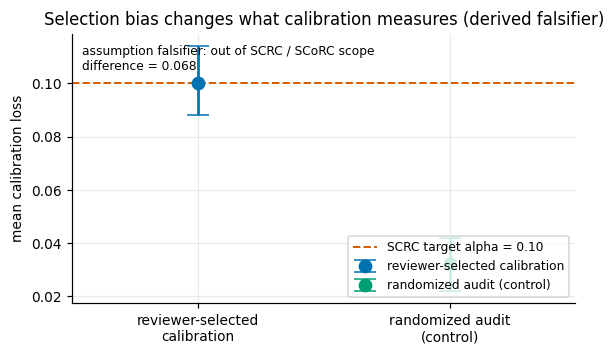

In [17]:
fig, ax = plt.subplots(figsize=(5.4, 3.3))
arm_means = [comparison["selected_mean"], comparison["audit_mean"]]
arm_lo = [arm_means[0] - selected_ci[0], arm_means[1] - audit_ci[0]]
arm_hi = [selected_ci[1] - arm_means[0], audit_ci[1] - arm_means[1]]
ax.errorbar(
    [0],
    [arm_means[0]],
    yerr=[[arm_lo[0]], [arm_hi[0]]],
    fmt="o",
    markersize=8,
    capsize=7,
    linewidth=1.8,
    color=PALETTE["blue"],
    ecolor=PALETTE["blue"],
    label="reviewer-selected calibration",
)
ax.errorbar(
    [1],
    [arm_means[1]],
    yerr=[[arm_lo[1]], [arm_hi[1]]],
    fmt="o",
    markersize=8,
    capsize=7,
    linewidth=1.8,
    color=PALETTE["green"],
    ecolor=PALETTE["green"],
    label="randomized audit (control)",
)
ax.axhline(
    0.10,
    color=PALETTE["vermillion"],
    linestyle="--",
    linewidth=1.3,
    label="SCRC target alpha = 0.10",
)
ax.set_xticks([0, 1])
ax.set_xticklabels(["reviewer-selected\ncalibration", "randomized audit\n(control)"])
ax.set_xlim(-0.5, 1.5)
ax.set_ylabel("mean calibration loss")
ax.set_title("Selection bias changes what calibration measures (derived falsifier)")
ax.text(
    0.02,
    0.96,
    "assumption falsifier: out of SCRC / SCoRC scope\n"
    f"difference = {comparison['risk_difference']:.3f}",
    transform=ax.transAxes,
    fontsize=8,
    va="top",
    color="black",
)
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

## What this notebook did, and what it did not

**Verified against the sources (source-backed).** The Eq. (2)/Eq. (6a) CCEM probability/NLL machinery
on a hand-computed case; the analytic gradient of the implemented CCEM objective against finite
differences; SCRC's Eq. (2)/(3)/(6) quantities and the exchangeable control's mean selected risk
against its target; SCoRC's Algorithm 1 pieces (Clopper-Pearson LCB, empirical-Bernstein slack,
deterministic filter, `INFEASIBLE` branch) inside a full toy ledger and in a 200-replication joint
certificate whose coverage clears `1 - delta`; and the two published slack formulas side by side.

**Only ever *derived here*.** The synthetic streams, the CPU linear-softmax adaptation, the
one-stage SCRC collapse, the toy candidate grid, the fixed-variance slack curve, and the toy
calibration arrays. None of it is a production claim, uses real data, or reproduces a paper table.

**Deliberately not claimed.** SCoRC benchmark numbers are not quoted;
the reviewer-selection, non-exchangeability, heavy-tailed-dollar, rejected-case and drift questions
stay *out of scope* and appear only as measured falsifiers (the last one above, the rest on the
walkthrough notebooks).